# Arbol de Decisión y Bosque Aleatorio


## Parte 1: árbol de Decisión(Decision Tree)

In [30]:
# Importar Librerias

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [31]:
mydata =load_iris()

x = mydata.data
y = mydata.target #Etiquetas

print(x.shape)
print(y.shape)

(150, 4)
(150,)


In [32]:
mydata.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [33]:
mydata.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [34]:
# Triple partición

X_tv, X_test, y_tv, y_test = train_test_split(x, y, test_size=.2, shuffle=True, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=.25, shuffle=True, random_state=1)

print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de validación:', X_val.shape)
print('Tamaño del conjunto de prueba', X_test.shape)

Tamaño del conjunto de entrenamiento: (90, 4)
Tamaño del conjunto de validación: (30, 4)
Tamaño del conjunto de prueba (30, 4)


C:\Users\mario\AppData\Local\Temp\ipykernel_26552\442949513.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(x, labels=mydata.feature_names)


{'whiskers': [<matplotlib.lines.Line2D at 0x1a134d97390>,
 'caps': [<matplotlib.lines.Line2D at 0x1a134d97110>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a134d974d0>,
 'medians': [<matplotlib.lines.Line2D at 0x1a134d95e50>,
 'fliers': [<matplotlib.lines.Line2D at 0x1a134d960d0>,
 'means': []}

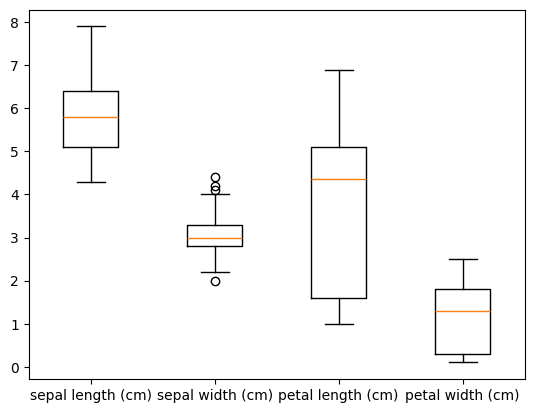

In [35]:
plt.boxplot(x, labels=mydata.feature_names)

In [36]:
modeloDT = DecisionTreeClassifier()   # Incializamos el modelo con los hiperparámetros predeterminados.

clf = modeloDT.fit(X_train, y_train)   # Entrenamos con el conjunto de entrenamiento para obtener nuestro primer clasificador (clf)

# Podemos observar el desempeño en el conjunto de entrenamieto para verificar
# el subentrenamiento o sobreentrenamiento, pero no para evaluar el modelo en sí:
print('Exactitud en el conjunto de entrenamiento: %.2f' % clf.score(X_train, y_train))

# Así, el conjunto con el que nos interesa evaluar el desempeño es con los de validación,
# así que calculamos primero sus predicciones y después las usamos para evaluar el modelo:

predi = clf.predict(X_val)     # Obtenemos predicciones de 0s, 1s o 2s para cada clase

print('Exactitud en el conjunto de validación: %.2f' % clf.score(X_val, y_val))

Exactitud en el conjunto de entrenamiento: 1.00
Exactitud en el conjunto de validación: 0.97


In [37]:
print(confusion_matrix(y_val, predi)) #Matriz de confusión en el conjunto de validación

[[ 9  0  0]
 [ 0 10  0]
 [ 0  1 10]]


In [38]:
print(confusion_matrix(y_val, predi)/y_val.shape[0])

[[0.3        0.         0.        ]
 [0.         0.33333333 0.        ]
 [0.         0.03333333 0.33333333]]


In [39]:
clf.score(X_val, y_val)

0.9666666666666667

In [40]:
%pip install pydotplus graphviz


Note: you may need to restart the kernel to use updated packages.


In [41]:
## Graficar el arbol de decisión
from sklearn import tree
import pydotplus
from IPython.display import Image

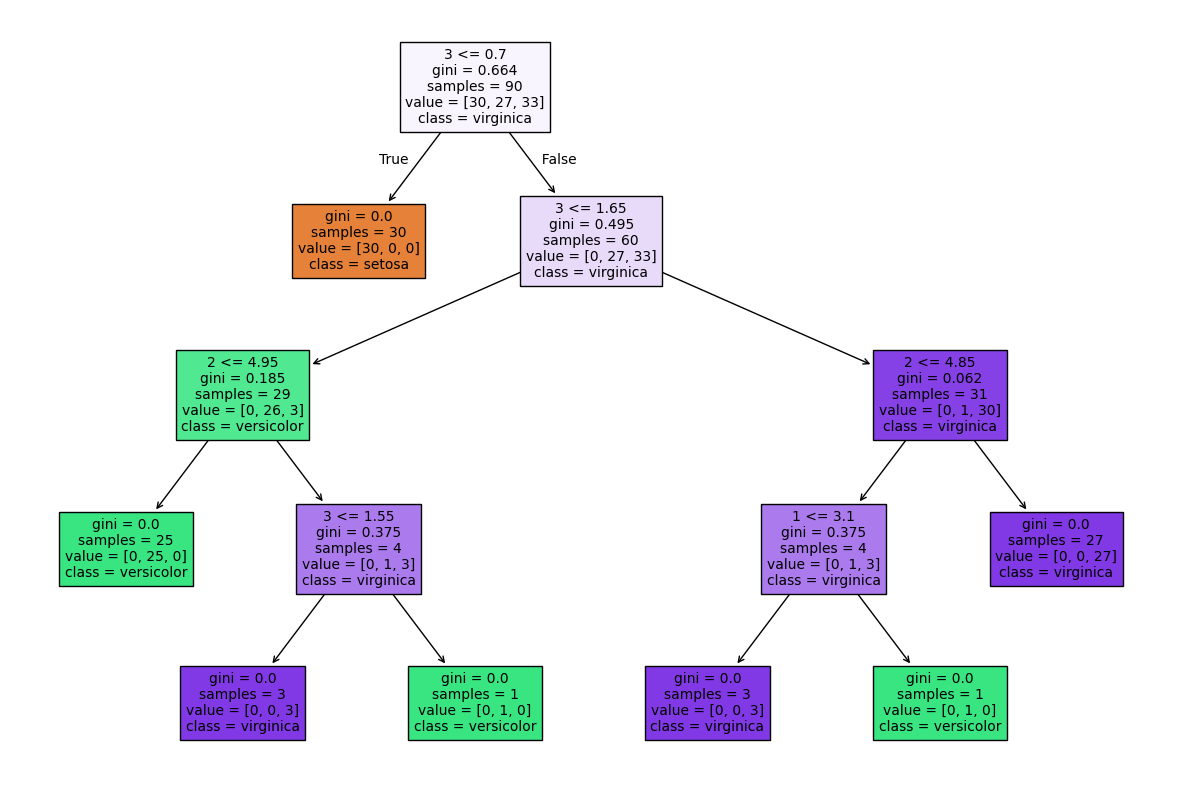

In [42]:
# 1. Configurar el tamaño de la imagen

plt.figure(figsize=(15, 10))

# 2. Dibujar el árbol directamente

tree.plot_tree(decision_tree=clf,
 max_depth=None,
feature_names=list(pd.DataFrame(X_train).columns.astype(str)),
class_names=[str(c) for c in mydata.target_names],
filled=True,
 proportion=False,
fontsize=10)

# 3. Mostrar la imagen en Jupyter
plt.show()

## Parte 2: Random forest(Bosque Aleatorio)

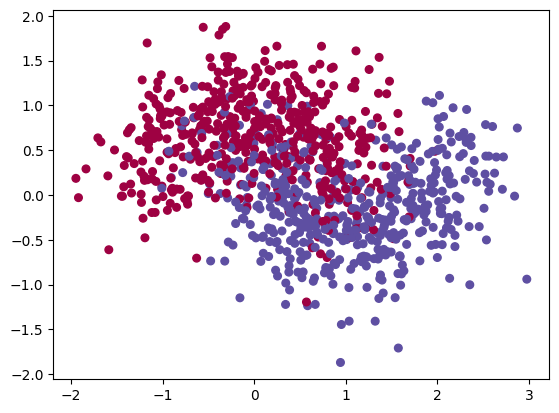

In [43]:
N=1000  # total de datos a generar en la muestra.
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=N, noise=0.4, random_state=17)

plt.scatter(X[:,0], X[:,1], c=y, s=30, cmap=plt.cm.Spectral);

In [44]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=.4, shuffle=True, random_state=17)

mimodelo = RandomForestClassifier()

clf = mimodelo.fit(Xtrain, ytrain)

results = clf.predict(Xtest)

confusion_matrix(ytest, results)

array([[166,  36],
       [ 32, 166]])

In [45]:
clf.score(Xtest,ytest)  # es la Exactitud (accuracy)

0.83

In [46]:
clf.feature_importances_

array([0.45532959, 0.54467041])

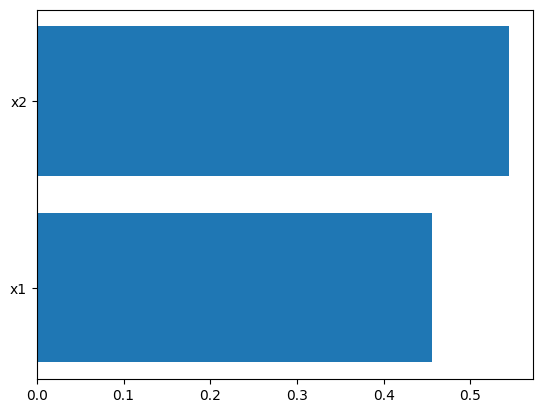

In [47]:
plt.barh(['x1','x2'], width=clf.feature_importances_);

In [50]:
## Algunos de lo hiperparámetros del clasificador bosque aleatorio:

mimodelo2 = RandomForestClassifier(n_estimators=10,  # número de árboles en el Forest y después promedia por votación.
                                   criterion='gini',   # métrica para determinar las ramas. También puede ser: 'entropy', para la GananciaDeInformación (IG).
                                   max_depth=2, # Depth=k : máximo 2^k líneas/ramas.
                                   min_samples_split = 6,  # mínimo de puntos muestrales requeridos en un nodo para hacer la ramificación. Puede ser fracción de 0 a 1.
                                   min_samples_leaf = 4,  # mínimo de puntos muestrales que deben quedar en cada nueva ramificación (hojas). Puede ser fracción de 0 a 1.
                                   max_features= 'sqrt',   # 'auto' no es válido en versiones recientes; usar 'sqrt' o 'log2' o int/float.
                                   max_leaf_nodes=16,  # solo nos quedamos con las mejores k hojas.
                                   bootstrap=True,  # Cada Árbol se muestrea seleccionando la cantidad de datos del conjunto de entrenamiento, pero con reemplazo. False:los datos usados en cada árbol simpre es el mismo, el Train-set.
                                   oob_score=True,  # en caso de utilizar Out-of-bag samples.
                                   verbose=0,     # tipo de despliega de información durante el entrenamiento.
                                   n_jobs=-1,    # total de hilos a usar en las rutinas paralelizables: "-1" :usar todos los posibles.
                                   max_samples=None,   # Cuando se usa Boostrap, es el total de datos de Xtrain a usar en cada árbol. "None" usará Xtrain[0].
                                   random_state=19)


In [51]:
clf2 = mimodelo2.fit(Xtrain,ytrain)
clf2.score(Xtest,ytest)

c:\Users\mario\.conda\envs\cls1\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


0.855